Top-K采样

In [4]:
import numpy as np

prods = np.array([0.5, 0.05, 0.1, 0.3, 0.05])
words = np.array(["I", "am", "learning", "LLM", "<eos>"])


top_k = 3
# np.argsort 返回的是排序后的索引 [1, 3, 0, 4, 2]
# [::-1] 反转索引，得到 [2, 0, 3, 4, 1]
# [:top_k] 取前 top_k 个索引
# words[np.argsort(prods)[::-1][:top_k]] 取前 top_k 个索引对应的单词
top_k_prods = prods[np.argsort(prods)[::-1][:top_k]]
print(top_k_prods)

top_k_words = words[np.argsort(prods)[::-1][:top_k]]
print(top_k_words)

top_k_prods = top_k_prods / np.sum(top_k_prods)
print(top_k_prods)


[0.5 0.3 0.1]
['I' 'LLM' 'learning']
[0.55555556 0.33333333 0.11111111]


Top-P 采样

In [7]:
prods = np.array([0.5, 0.05, 0.1, 0.3, 0.05])
words = np.array(["I", "am", "learning", "LLM", "<eos>"])

top_p = 0.8
top_p_prods = prods[np.argsort(prods)[::-1]]
print(top_p_prods)
top_p_words = words[np.argsort(prods)[::-1]]
print(top_p_words)

top_p_cumulative_probs = np.cumsum(top_p_prods)
print(top_p_cumulative_probs)

# 找到累计概率大于等于top_p的索引
top_p_index = np.argmax(top_p_cumulative_probs >= top_p)
print(top_p_index)
print(top_p_words[:top_p_index+1])

[0.5  0.3  0.1  0.05 0.05]
['I' 'LLM' 'learning' '<eos>' 'am']
[0.5  0.8  0.9  0.95 1.  ]
1
['I' 'LLM']


# Temperature的影响


 ----Temperature = 0.5 ----
I: 0.70
am: 0.01
learning: 0.03
LLM: 0.25
<eos>: 0.01

 ----Temperature = 1.0 ----
I: 0.50
am: 0.05
learning: 0.10
LLM: 0.30
<eos>: 0.05

 ----Temperature = 2.0 ----
I: 0.35
am: 0.11
learning: 0.16
LLM: 0.27
<eos>: 0.11


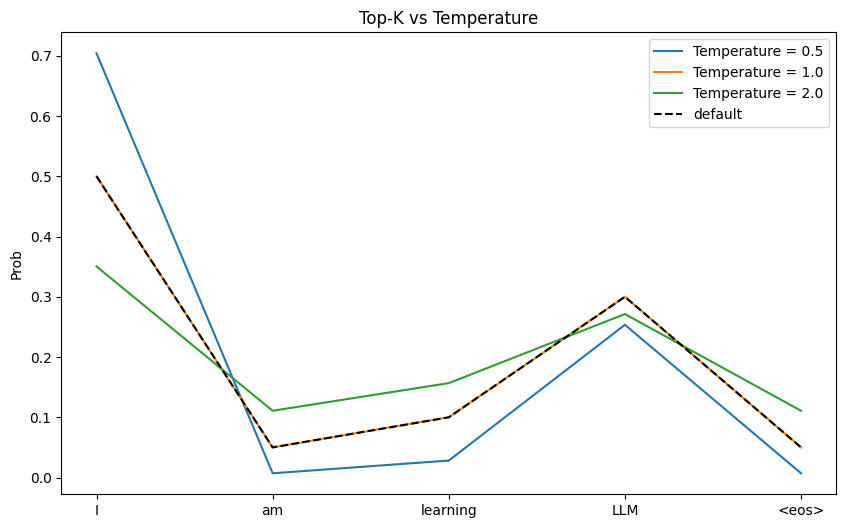

In [9]:
import matplotlib.pyplot as plt

# 概率分布
probs = np.array([0.5, 0.05, 0.1, 0.3, 0.05])
words = ["I", "am", "learning", "LLM", "<eos>"]

# 设置不同的temperatures
# p^(1/temperature)
temperatures = [0.5, 1.0, 2.0]


# 创建一个图表
plt.figure(figsize=(10, 6))

# 遍历不同的温度
for temp in temperatures:
    # 使用temperature调整概率分布
    adjusted_prob = probs ** (1.0 / temp) 
    adjusted_prob = adjusted_prob / np.sum(adjusted_prob)

    # 打印调整后的 temperature 概率分布
    print(f"\n ----Temperature = {temp} ----")
    for i, prob in enumerate(adjusted_prob):
        print(f"{words[i]}: {prob:.2f}")

    plt.plot(words, adjusted_prob, label=f"Temperature = {temp}")

# 绘制原始概率分布的对比
plt.plot(words, probs, label="default", linestyle='--', color="black")

# 添加图表信息
plt.ylabel("Prob")
plt.title("Top-K vs Temperature")
plt.legend()

plt.show()

In [14]:
import os
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

# 设置 no_proxy 和 NO_PROXY
os.environ['no_proxy'] = "localhost,.byted.org,byted.org,.bytedance.net,bytedance.net,.byteintl.net,.tiktok-row.net,.tiktok-row.org,127.0.0.1,::1"
os.environ['NO_PROXY'] = os.environ['no_proxy']   # 保持两者一致

# 设置 Hugging Face 镜像端点
os.environ['HF_ENDPOINT'] = "http://huggingface-proxy-sg.byted.org"   # 或使用 https

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# 指定模型
model_name = "distilgpt2"

# 加载分词器和模型
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
device = torch.device("cuda")

# 讲模型copy到GPU上
model.to(device)

# 输入文本
input_text = "I have a dream, and I"

# 编码输入文本
inputs = tokenizer.encode(input_text, return_tensors='pt').to(device)
attention_mask = torch.ones_like(inputs).to(device)

# 设置TOP-K, TOP-P和温度系数
top_k = 10
top_p = 0.9
temperature = 0.001


# 生成文本，利用top-k, top-p和文本来控制采样
#关闭梯度计算，避免占用内存
with torch.no_grad():
    outputs = model.generate(
        # 输入文本
        inputs,
        # 注意力掩码
        attention_mask=attention_mask,
        # 最大生成长度
        max_length=50,
        # 是否使用采样
        do_sample=True,
        # 同时启用top_k和top_p：先应用 Top-K 过滤，再在剩余 token 中应用 Top-P 过滤，效果最好
        # TOP-K采样参数
        top_k=top_k,
        # TOP-P采样参数
        top_p=top_p,
        # 温度系数
        temperature=temperature,
        # 是否禁用重复ngramgram：防止循环语句：生成 "今天天气" 后，不会再生成 "今天天气"，但可以单独出现 "今天" 或 "天气"
        # 或者 repetition_penalty repetition_penalty=1.2，所有已经生成过的 token 的概率都会乘以 0.8
        no_repeat_ngram_size=2,
        # 填充token id
        pad_token_id=tokenizer.eos_token_id
    )

# 解码生成的文本
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print("结合TOP-K 和 TOP-P采样生成的文本：")
print(generated_text)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

结合TOP-K 和 TOP-P采样生成的文本：
I have a dream, and I'm going to be a part of it. I want to do it for the first time.

"I'm not going anywhere. It's not my dream. But I am going. And I hope that
